In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
# PARTE 1
# 1. Crosstab Analysis
# - Create a crosstab between the product `category` and the `isBestSeller` status. 

crosstab = pd.crosstab(df['category'], df['isBestSeller'])

crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


La tabla cruzada entre la categoría del producto y su estado de best-seller muestra una primera tabla de números brutos es decir, cuenta cuántos productos hay en cada combinación. 

Por en la categoría Arts & Craft:
- False = nos dice cúantos productos de Arts no son best seller, en este caso, 9319.
- True = nos dice cúantos productos de Arts sí son best seller, en este caso, 230.

In [3]:
# - Are there categories where being a best-seller is more prevalent?

proporcion_bestseller = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')*100
proporcion_bestseller = proporcion_bestseller.sort_values(True, ascending=False).round(2)

proporcion_bestseller

isBestSeller,False,True
category,,
Grocery,94.19,5.81
Smart Home Security & Lighting,94.23,5.77
Health & Personal Care,94.23,5.77
Mobile Phone Accessories,95.75,4.25
Power & Hand Tools,96.47,3.53
...,...,...
"CD, Disc & Tape Players",100.00,0.00
General Music-Making Accessories,100.00,0.00
Snowboard Boots,100.00,0.00


Los porcentajes proporcionales dentro de cada categoría muestran que: 

- True → % de productos de esa categoría que SÍ son best-seller
- False → % de productos de esa categoría que NO son best-seller

Y siempre suman 100% entre los dos. Por ejemplo Grocery:

- 5.81% son best-sellers
- 94.19% no son best-sellers
- 5.81 + 94.19 = 100% 

Respondiendo a la pregunta, las categorías donde ser best-seller es más común son Grocery (5.81%), Smart Home Security (5.77%) y Health & Personal Care (5.77%).

Sin embargo, en todas las categorías el porcentaje de best-sellers es muy bajo porque el máximo es solo 5.81%. Esto indica que ser best-seller es poco común 
independientemente de la categoría.

In [21]:
# 2. Statistical Tests
#   - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category

# H0: category e isBestSeller son independientes (no hay relación)
# H1: existe asociación entre category e isBestSeller

chi2, chi2_p_value, _, _ = stats.chi2_contingency(crosstab)

print(f"Chi-cuadrado: {chi2:.2f}")
print("P-valor:      menor que 0.0001 (prácticamente 0)")

Chi-cuadrado: 36540.20
P-valor:      menor que 0.0001 (prácticamente 0)


**Chi-square test**

- H0: category e isBestSeller son independientes
- H1: existe asociación entre las dos variables

Chi-cuadrado = 36,540.20 y p-valor prácticamente 0 (mucho menor que 0.0001). Como p < 0.05, rechazamos H0 → la categoría SÍ influye en ser best-seller, no es casualidad.

El chi-cuadrado mide cuánto se aleja la realidad de lo que pasaría por azar; el p-valor nos dice si esa diferencia es estadísticamente significativa.

In [5]:
# - Compute Cramér's V to understand the strength of association between best-seller status and category

from scipy.stats.contingency import association

cramers_v = association(crosstab, method="cramer")

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1223


Resultado de Cramér's V: 0.1223 — relación débil.

Recordatorio de valores:

- 0 → ninguna relación
- 0.1 → relación débil ← estamos aquí
- 0.3 → relación moderada
- 0.5 → relación fuerte

Insight. Entonces combinando Chi-square y Cramér's V la conclusión es:

- Chi-square → la relación existe y no es casualidad (p-valor prácticamente 0)
- Cramér's V → pero esa relación es débil (0.12)

Es decir, la categoría sí influye en ser best-seller, pero no de forma muy fuerte. Hay otros factores que probablemente influyen más.

Nota: con un dataset tan grande (más de 2 millones de filas), incluso una asociación débil como 0.12 puede ser relevante en la práctica. El volumen de datos hace que detectemos relaciones reales aunque sean pequeñas.

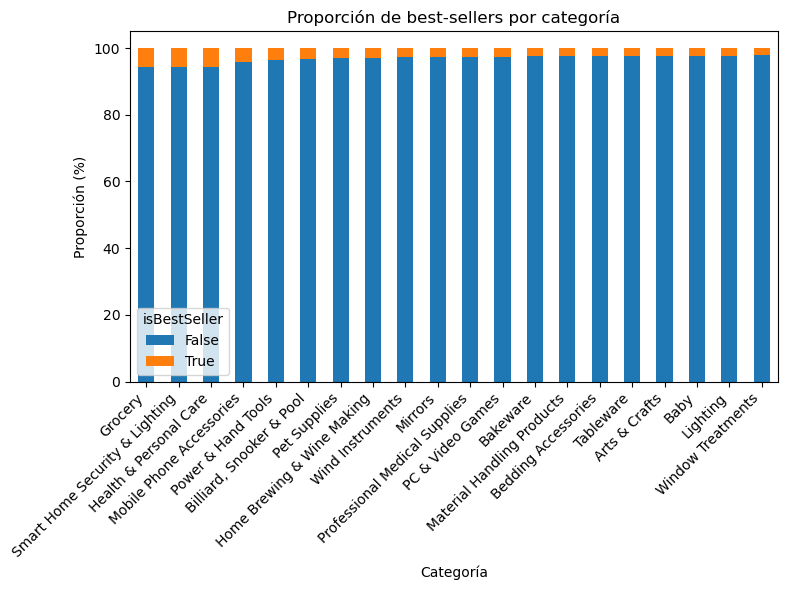

In [6]:
# 3. Visualization
#   - Visualize the relationship between product categories and the best-seller status using a stacked bar chart

proporcion_bestseller.head(20).plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Proporción de best-sellers por categoría')
plt.xlabel('Categoría')
plt.ylabel('Proporción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Insights:
- Cada barra llega al 100% dividida en azul y naranja
- la parte naranja (best sellers)es muy pequeña en todas categorías
- **'Grocery', 'Smart Home Sec' & 'Health'** tienen la parte naranja más grande (aunque en pequeña proporción visualemente)

In [7]:
# PARTE 2
# 0. Preliminary Step: Remove outliers in product prices

# Primero visualizamos los números así entiendo mejor lo que hago
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")


Q1: 9.99
Q3: 45.99
IQR: 36.00
Límite inferior: -44.01
Límite superior: 99.99


In [8]:
# Luego aplicamos función del notebook de clase para eliminar outliers

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df_sin_outliers = df[(df[column] >= limite_inferior) & (df[column] <= limite_superior)]
    
    return df_sin_outliers

df_sin_outliers = remove_outliers_iqr(df, 'price')

print(f"Filas originales:    {df.shape[0]}")
print(f"Filas sin outliers:  {df_sin_outliers.shape[0]}")
print(f"Outliers eliminados: {df.shape[0] - df_sin_outliers.shape[0]}")

Filas originales:    2443651
Filas sin outliers:  2115963
Outliers eliminados: 327688


Insights:


- **Q1: £9.99** → el 25% de productos más baratos cuestan menos de £9.99
- **Q3: £45.99** → el 75% de productos cuestan menos de £45.99
- **IQR: £36** → el 50% central de productos está en un rango de £36
- **Límite inferior: -£44.01** → ningún producto tiene precio negativo, así que no se elimina nada por abajo
- **Límite superior: £99.99** → todo producto por encima de £99.99 es outlier
- **327,688 outliers eliminados** → productos con precio mayor de £99.99

Nos quedamos con 2115963 productos para el resto del análisis.

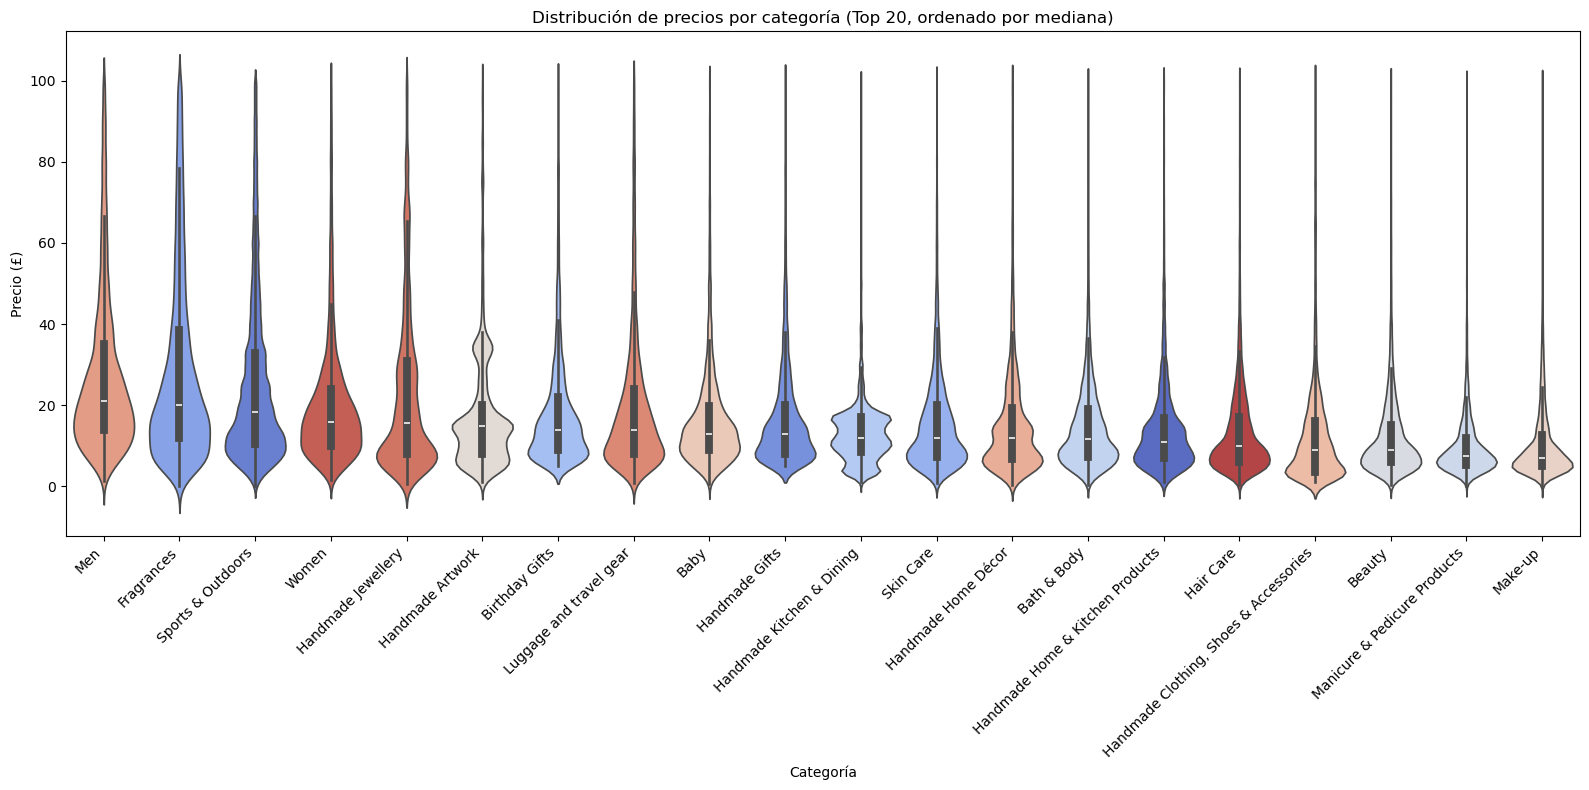

In [22]:
# 1. Violin Plots

# top 20 cat
top20_categorias = df_sin_outliers['category'].value_counts().head(20).index
df_top20 = df_sin_outliers[df_sin_outliers['category'].isin(top20_categorias)]

# violin plot

orden_mediana = df_top20.groupby('category')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top20, x='category', y='price', hue='category', palette="coolwarm", legend=False, order=orden_mediana)
plt.title('Distribución de precios por categoría (Top 20, ordenado por mediana)')
plt.xlabel('Categoría')
plt.ylabel('Precio (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

De forma general se puede decir que:
- Todos los violines tienen la parte más ancha cerca de £0-£20 — confirma que la mayoría de productos son baratos en todas las categorías
- Todos tienen cola hacia arriba hasta ~£100 — hay productos más caros en todas las categorías pero son pocos-

Respecto a las categorías:
- Fragrances tiene el violín más ancho en precios medios (~£20-£40) — productos más caros que el resto
- Handmade Artwork también tiene el violín más ancho en precios más altos
- Manicure & Pedicure y Bath & Body tienen violines muy estrechos y pegados al suelo — productos muy baratos y concentrados

El punto blanco en el centro de cada violín es la mediana.


In [10]:
# - Which product category tends to have the highest median price? Don't filter here by top categories

mediana_por_categoria = df_sin_outliers.groupby('category')['price'].median().sort_values(ascending=False)

mediana_por_categoria.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

Desktop PCs es la categoría con la mediana de precio más alta £74, seguida de Boxing Shoes (£69.79) y Tablets (£69)

Estas categorias no aparecen en el violin plot porque no están en el top 20 por número de productos, hay pocas unidades listadas pero son caras. Por eso el enunciado pedía hacer las dos cosas por separado.

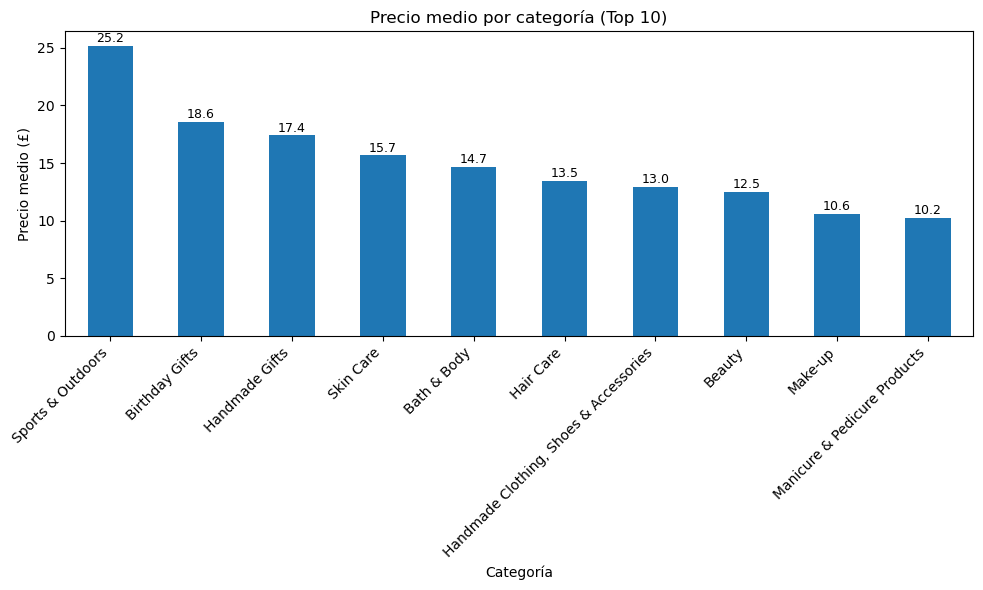

In [23]:
# 2. Bar Charts
# - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).

top10_categorias = df_sin_outliers['category'].value_counts().head(10).index
precio_medio = df_sin_outliers[df_sin_outliers['category'].isin(top10_categorias)].groupby('category')['price'].mean().sort_values(ascending=False)

ax = precio_medio.plot(kind='bar', figsize=(10, 6))
plt.title('Precio medio por categoría (Top 10)')
plt.xlabel('Categoría')
plt.ylabel('Precio medio (£)')
plt.xticks(rotation=45, ha='right')

# Etiquetas de valor encima de cada barra
for i, v in enumerate(precio_medio):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
# - Which product category commands the highest average price? Don't filter here by top categories

precio_medio_todas = df_sin_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
precio_medio_todas.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

**Bar chart — Top 10 categorías por número de productos:**

Sports & Outdoors tiene el precio medio más alto (25) del top 10

Manicure & Pedicure Products el más bajo (10)

En general los precios medios están entre 10 y 25 — rango bastante estrecho

**Sin filtrar — categoría con precio medio más alto:**

Motherboards lidera con 68.77 de media

Seguida de Boxing Shoes 67.42 y Desktop PCs (66.92)


De nuevo estas categorías no aparecen en el bar chart porque tienen pocos productos listados pero son caros.

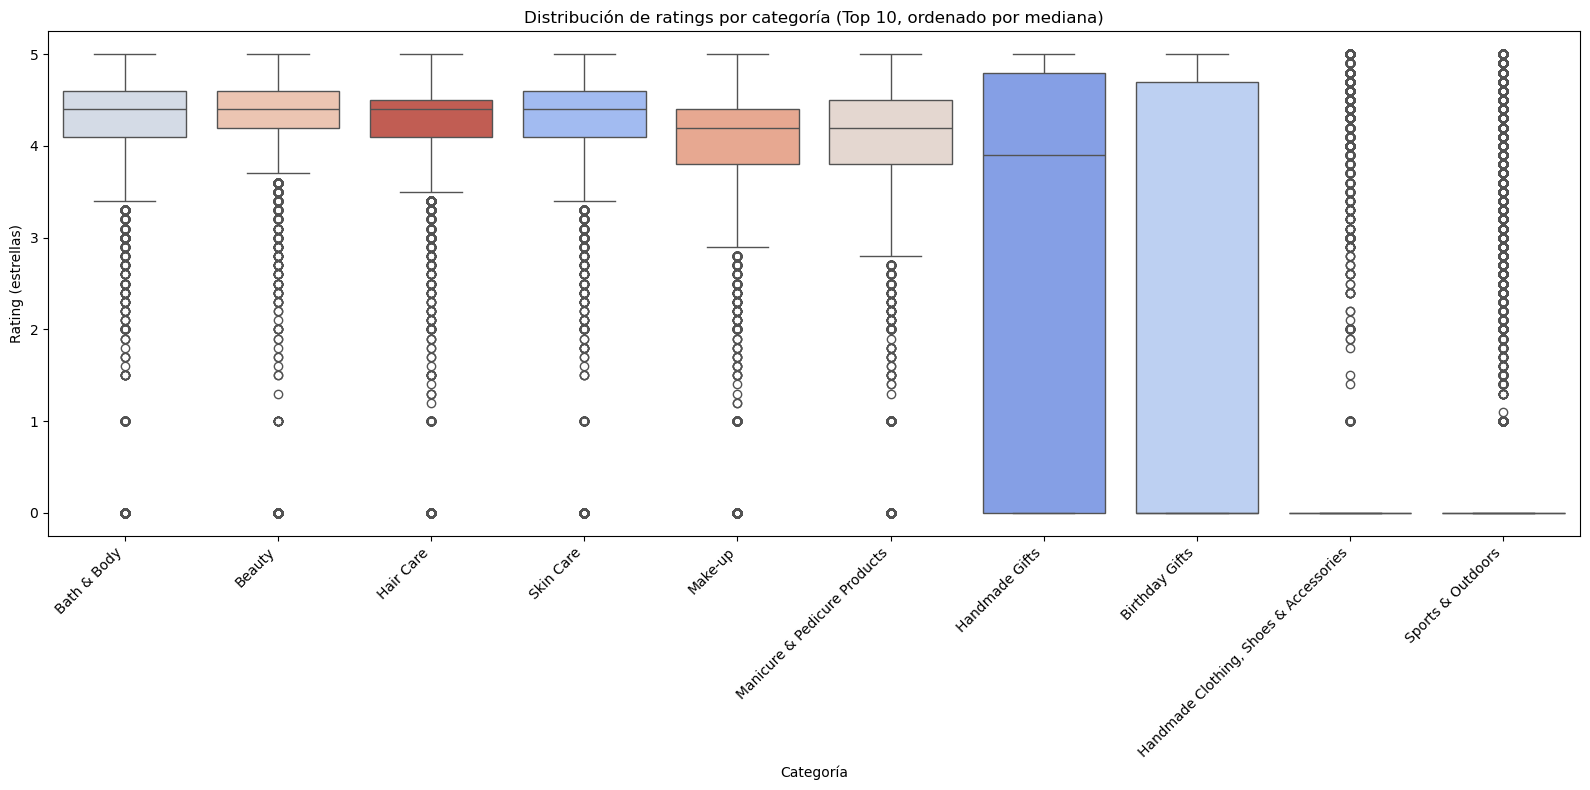

In [24]:
# 3. Box Plots 
# - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
top10_categorias = df_sin_outliers['category'].value_counts().head(10).index
df_top10 = df_sin_outliers[df_sin_outliers['category'].isin(top10_categorias)]

# Ordenamos por mediana de rating
orden_rating = df_top10.groupby('category')['stars'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_top10, x='category', y='stars', hue='category', palette="coolwarm", legend=False, order=orden_rating)
plt.title('Distribución de ratings por categoría (Top 10, ordenado por mediana)')
plt.xlabel('Categoría')
plt.ylabel('Rating (estrellas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# - Which category tends to receive the highest median rating from customers? Don't filter here by top categories
mediana_rating = df_sin_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
mediana_rating.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

**Box plot — Top 10 categorías por número de productos:**

- La mayoría de categorías (Skin Care, Beauty, Hair Care, Bath & Body, Make-up) concentran sus ratings entre 4 y 4.6, con outliers por debajo (productos con mala nota real)
- Sports & Outdoors y Handmade Clothing tienen la caja aplastada en 0, la mayoría de sus productos tienen stars = 0
- Handmade Gifts y Birthday Gifts tienen cajas enormes (de 0 a 4.7), mezcla de productos sin valorar y bien valorados

El 0 no significa "valoración de cero estrellas", sino producto sin reseñas todavía. No es que la gente odie esos productos, es que aún nadie los ha puntuado. Esto distorsiona las medianas de esas categorías.

Respecto **categoría con la mediana de rating más alta (sin filtrar)**, Computer Memory lidera con 4.7, seguida de un grupo empatado en 4.6 (Building & Construction Toys, Office Paper, Luxury Food & Drink, etc.). Igual que con el precio, estas categorías no aparecen en el box plot porque tienen pocos productos pero bien valorados.

In [15]:
# PARTE 3
# 1. Correlation Coefficients
# - Calculate the correlation coefficient between `price` and `stars`.
correlacion = df_sin_outliers['price'].corr(df_sin_outliers['stars'])

print(f"Correlación price vs stars: {correlacion:.4f}")

Correlación price vs stars: -0.0777


**- Is there a significant correlation between product price and its rating?**

**Correlación price vs stars: -0.0777**

Correlación muy débil, prácticamente nula. El signo negativo indicaría que a más precio, ligeramente menos estrellas, pero el valor es tan pequeño (< 0.1) que no hay relación lineal apreciable entre las dos variables.

Importante: Pearson solo mide relación *lineal*. Que salga 0 no significa que sean totalmente independientes, sino que no se mueven juntas de forma lineal.

**Insight:** un producto no recibe mejor nota por ser más caro ni peor por ser barato. Subir el precio no penaliza las reseñas de forma apreciable.

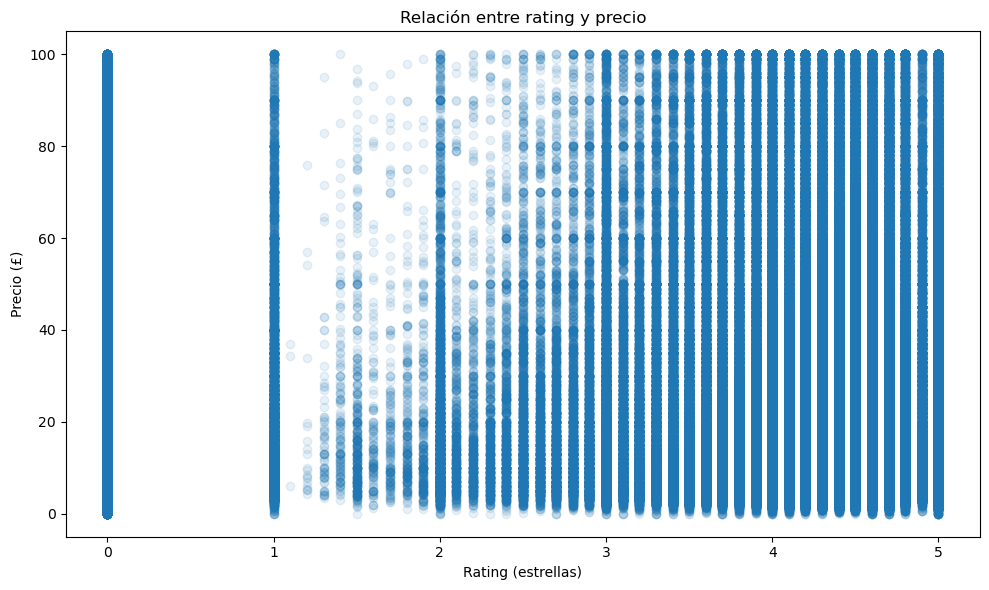

In [16]:
# 2. Visualizations
# - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
plt.figure(figsize=(10, 6))
plt.scatter(df_sin_outliers['stars'], df_sin_outliers['price'], alpha=0.1)
plt.title('Relación entre rating y precio')
plt.xlabel('Rating (estrellas)')
plt.ylabel('Precio (£)')
plt.tight_layout()
plt.show()

**Scatter plot rating vs precio:**

Los puntos forman líneas verticales (stars va de 0.1 en 0.1, no es continuo), no una nube diagonal. En cada nota los precios van de £0 a £100 sin ninguna tendencia por lo que confirma visualmente la correlación nula.

- La franja densa en stars = 0 son productos sin reseña
- Las columnas entre 4 y 5 son las más saturadas → la mayoría de productos valorados se concentran ahí
- Hueco entre 0 y 1: un producto o tiene reseñas (mín. 1) o no tiene ninguna (0), no hay punto medio

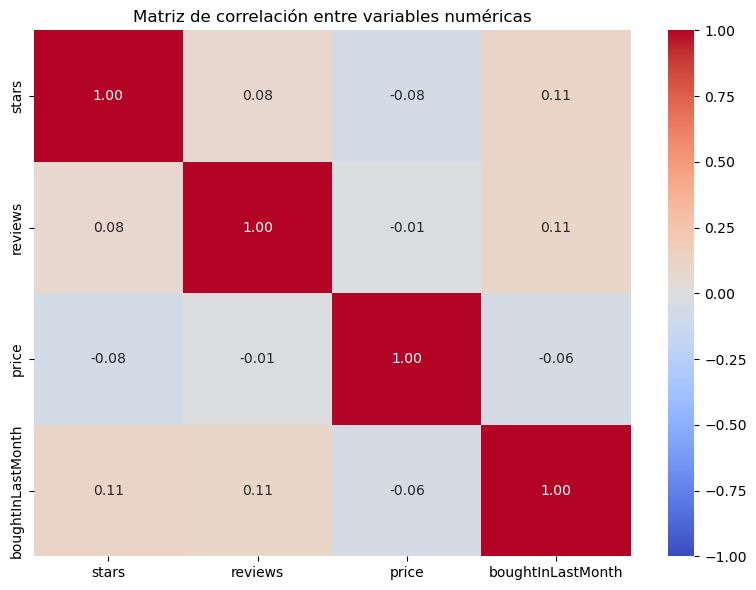

In [17]:
# - Use a correlation heatmap to visualize correlations between all numerical variables.
columnas_num = ['stars', 'reviews', 'price', 'boughtInLastMonth']
matriz_corr = df_sin_outliers[columnas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

**Heatmap de correlaciones:**

No hay relaciones lineales apreciables entre ninguna de las variables fuera de la diagonal, todos los valores están entre -0.08 y 0.11 (insignificantes).

- price–stars = -0.08 → es muy débil
- price–reviews = -0.01 → es nula
- price–boughtInLastMonth = -0.06 → el precio tampoco predice las ventas del último mes
- Los más altos (stars–boughtInLastMonth y reviews–boughtInLastMonth = 0.11) siguen siendo insignificantes

**Insight:** ninguna métrica explica linealmente a las demás. El precio no determina ni la valoración ni las ventas; estas dependen de factores que no están en el dataset.

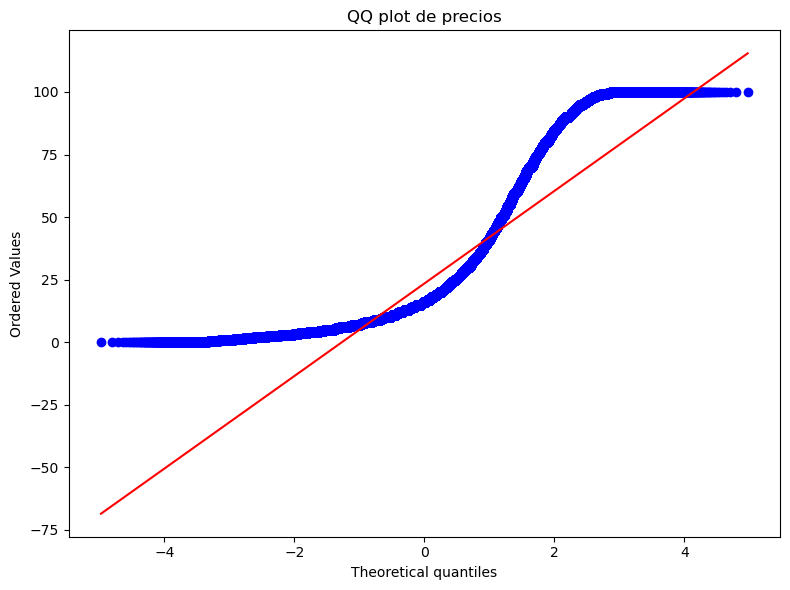

In [18]:
# - Examine if product prices typically follow a normal distribution using a QQ plot.
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(df_sin_outliers['price'], dist="norm", plot=plt)
plt.title('QQ plot de precios')
plt.tight_layout()
plt.show()

**QQ plot de precios:**

Los precios NO siguen una distribución normal. Los puntos forman una S en vez de seguir la línea diagonal:

- Abajo a la izquierda se aplastan cerca de £0 (los precios no pueden ser negativos y hay muchísimos productos baratos)
- En el centro se acercan a la recta (precios medios)
- Arriba a la derecha se aplanan en £100 (el techo que fijamos al quitar outliers)

Esta forma de S es típica de datos sesgados a la derecha: muchos valores bajos y una cola hacia arriba. Coincide con lo visto en los violin plots.

**Conexión con el filtrado:** esta asimetría hacia la derecha es justo la razón por la que en la Parte 2 quitamos outliers por encima de £99.99 con el método IQR. Aun después de limpiar, la distribución sigue sin ser normal porque el sesgo es estructural: los precios tienen suelo en £0 y una cola larga hacia arriba.

### Business Report — Amazon UK Product Insights

**Resumen**

Análisis de más de 2 millones de productos de Amazon UK (tras eliminar outliers de precio con el método IQR, quedando 2,115,963 productos por debajo de £99.99). El objetivo era entender qué relación hay entre categoría, precio, valoración y estado de best-seller para informar decisiones de pricing y catálogo.

**Conclusión principal:** las métricas de producto (precio, valoración, reseñas, ventas) son en gran medida independientes entre sí. No existe una palanca simple — como subir o bajar el precio — que mejore automáticamente la valoración o las ventas.


**1. Best-sellers por categoría**

- Ser best-seller es **poco común** en todas las categorías: ni la categoría con más proporción (Grocery) supera el 5.81%.
- El test Chi-square confirma que la categoría **sí influye** en ser best-seller (p prácticamente 0), pero Cramér's V = 0.12 indica que esa relación es **débil**.
- **Implicación de negocio:** la categoría aporta algo, pero no es determinante. El éxito de un best-seller depende sobre todo de otros factores (marca, marketing, demanda) no presentes en el dataset.

**2. Precios y valoraciones por categoría**

- La mayoría de productos son **baratos** (50% central entre £9.99 y £45.99); la distribución está fuertemente sesgada a la derecha.
- Las categorías con más productos (Sports & Outdoors, Skin Care, Beauty...) tienen precios medios bajos y similares (£10-£25).
- Las categorías con **precio más alto** son de nicho tecnológico (Motherboards, Desktop PCs, Tablets): pocos productos listados pero caros. No aparecen en los rankings por volumen.
- En valoraciones, la mediana más alta la tiene Computer Memory (4.7). Atención: muchas categorías muestran `stars = 0`, que **no es una mala nota sino ausencia de reseñas**.
- **Implicación de negocio:** volumen y precio no van de la mano. Las oportunidades de margen alto están en categorías de nicho caras, no en las de mayor tráfico.

**3. Relación entre precio y valoración**

- La correlación price–stars es **-0.0777**: no hay relación lineal apreciable.
- El heatmap confirma que **ninguna** variable numérica explica linealmente a las demás (todos los valores entre -0.08 y 0.11).
- Los precios **no siguen una distribución normal** (sesgo a la derecha confirmado en el QQ plot).
- **Implicación de negocio:** un producto no se valora mejor por ser más caro ni peor por ser barato. Subir el precio no penaliza las reseñas, lo que da margen para estrategias de pricing sin miedo a dañar la reputación del producto.


**Recomendaciones**

1. **Pricing flexible:** dado que precio y valoración son independientes, hay libertad para ajustar precios según margen/competencia sin temer un impacto en las reseñas.
2. **Foco en nicho de alto margen:** categorías tecnológicas de bajo volumen pero precio alto pueden ser oportunidades rentables frente a categorías saturadas y baratas.
3. **Limpiar el dato de valoraciones:** separar "0 = sin reseñas" de las notas reales antes de usar `stars` en cualquier modelo o KPI, para no distorsionar medianas.

**Limitaciones**

- El dataset no incluye costes, márgenes, marca ni datos de marketing, que probablemente expliquen mejor las ventas y el éxito de best-sellers.
- El análisis se hizo sin outliers de precio (>£99.99). Productos de gama alta quedan fuera y podrían comportarse distinto.